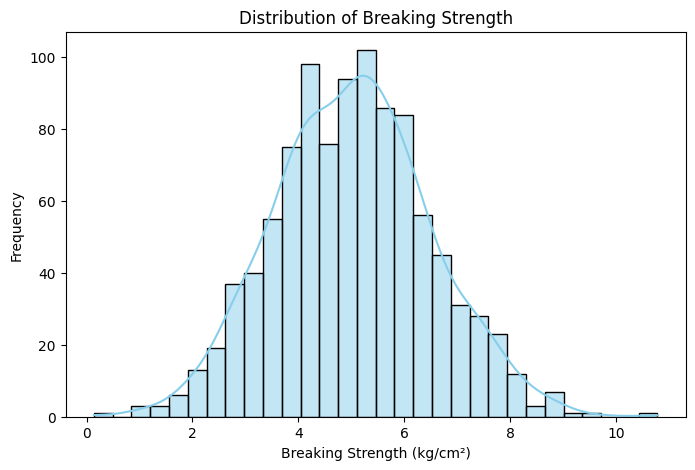

Category Probabilities:
 Category
Acceptable    0.698
Strong        0.155
Weak          0.147
Name: proportion, dtype: float64

Confusion Matrix:
 [[171   0   1]
 [  0  35   0]
 [  0   0  43]]

Classification Report:
               precision    recall  f1-score   support

  Acceptable       1.00      0.99      1.00       172
      Strong       1.00      1.00      1.00        35
        Weak       0.98      1.00      0.99        43

    accuracy                           1.00       250
   macro avg       0.99      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Generate synthetic data
np.random.seed(42)
mean_strength = 5
std_dev = 1.5
n_samples = 1000

breaking_strength = np.random.normal(mean_strength, std_dev, n_samples)

# Step 2: Create a DataFrame
data = pd.DataFrame({
    'Breaking_Strength': breaking_strength
})

# Step 3: Categorize breaking strength
def categorize_strength(x):
    if x < 3.5:
        return 'Weak'
    elif x <= 6.5:
        return 'Acceptable'
    else:
        return 'Strong'

data['Category'] = data['Breaking_Strength'].apply(categorize_strength)

# Step 4: Visualization
plt.figure(figsize=(8,5))
sns.histplot(data['Breaking_Strength'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Breaking Strength')
plt.xlabel('Breaking Strength (kg/cm²)')
plt.ylabel('Frequency')
plt.show()

# Probability of each category
category_prob = data['Category'].value_counts(normalize=True)
print("Category Probabilities:\n", category_prob)

# Step 5: Create a mock ML model
# Add some random noise features to simulate real-world input data
data['Material_Thickness'] = np.random.uniform(0.5, 2.0, n_samples)
data['Humidity'] = np.random.uniform(30, 80, n_samples)
data['Temperature'] = np.random.uniform(20, 40, n_samples)

# Prepare dataset for training
X = data[['Breaking_Strength', 'Material_Thickness', 'Humidity', 'Temperature']]
y = data['Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Step 6: Train a Decision Tree model
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Step 7: Evaluate model
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Proportion of gunny bags with breaking strength < 3.17 kg/cm²: 0.1112


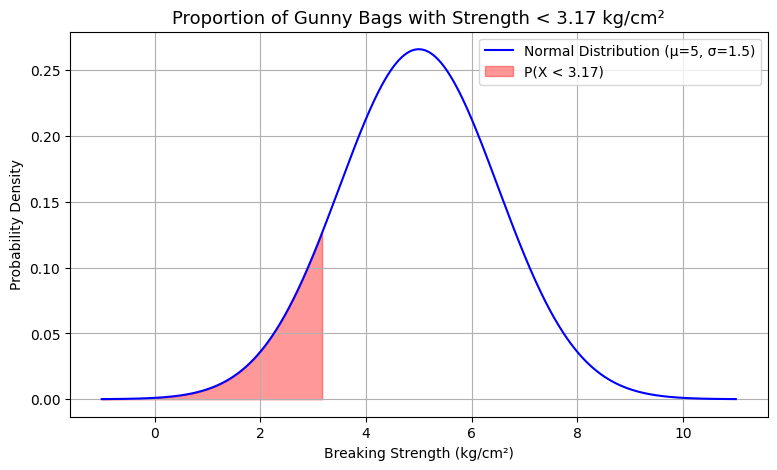

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Given parameters
mean_strength = 5       # mean (μ)
std_dev = 1.5           # standard deviation (σ)
threshold = 3.17        # value to test

# Step 1: Compute proportion (Probability P(X < 3.17))
probability = norm.cdf(threshold, mean_strength, std_dev)
print(f"Proportion of gunny bags with breaking strength < {threshold} kg/cm²: {probability:.4f}")

# Step 2: Visualization (Normal Distribution)
x = np.linspace(mean_strength - 4*std_dev, mean_strength + 4*std_dev, 1000)
y = norm.pdf(x, mean_strength, std_dev)

plt.figure(figsize=(9,5))
sns.lineplot(x=x, y=y, color='blue', label='Normal Distribution (μ=5, σ=1.5)')

# Shade area for X < threshold
x_shade = np.linspace(mean_strength - 4*std_dev, threshold, 1000)
y_shade = norm.pdf(x_shade, mean_strength, std_dev)
plt.fill_between(x_shade, y_shade, color='red', alpha=0.4, label=f'P(X < {threshold})')

# Step 3: Add graph details
plt.title('Proportion of Gunny Bags with Strength < 3.17 kg/cm²', fontsize=13)
plt.xlabel('Breaking Strength (kg/cm²)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

Proportion of gunny bags with breaking strength ≥ 3.6 kg/cm²: 0.8247


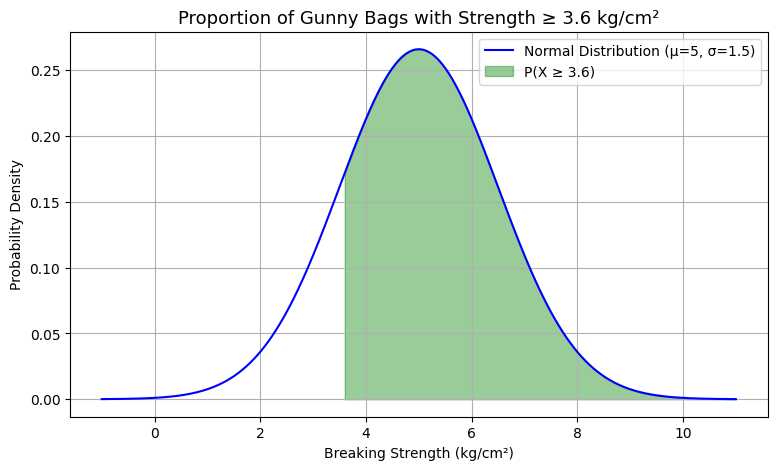

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Given parameters
mean_strength = 5       # mean (μ)
std_dev = 1.5           # standard deviation (σ)
threshold = 3.6         # value to test

# Step 1: Compute probability P(X ≥ 3.6)
# 1 - CDF gives area to the right of 3.6
probability = 1 - norm.cdf(threshold, mean_strength, std_dev)
print(f"Proportion of gunny bags with breaking strength ≥ {threshold} kg/cm²: {probability:.4f}")

# Step 2: Visualization (Normal Distribution)
x = np.linspace(mean_strength - 4*std_dev, mean_strength + 4*std_dev, 1000)
y = norm.pdf(x, mean_strength, std_dev)

plt.figure(figsize=(9,5))
sns.lineplot(x=x, y=y, color='blue', label='Normal Distribution (μ=5, σ=1.5)')

# Shade area for X ≥ threshold
x_shade = np.linspace(threshold, mean_strength + 4*std_dev, 1000)
y_shade = norm.pdf(x_shade, mean_strength, std_dev)
plt.fill_between(x_shade, y_shade, color='green', alpha=0.4, label=f'P(X ≥ {threshold})')

# Step 3: Graph labels and styling
plt.title('Proportion of Gunny Bags with Strength ≥ 3.6 kg/cm²', fontsize=13)
plt.xlabel('Breaking Strength (kg/cm²)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

Proportion of gunny bags with breaking strength between 5.0 and 5.5 kg/cm²: 0.1306


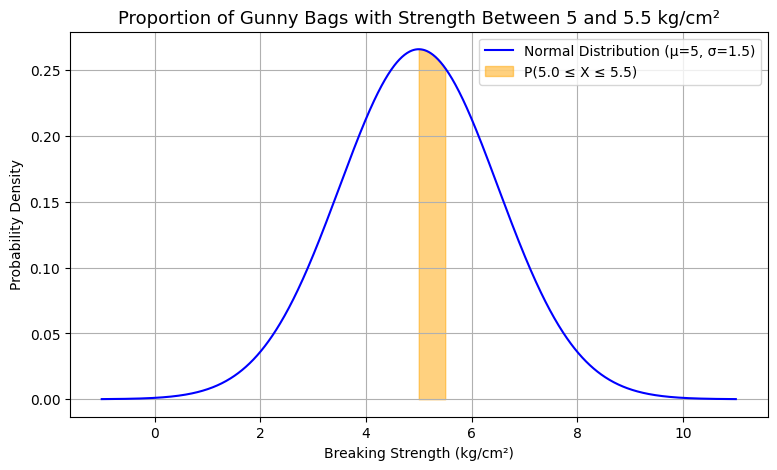

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Given parameters
mean_strength = 5       # mean (μ)
std_dev = 1.5           # standard deviation (σ)
lower_limit = 5.0
upper_limit = 5.5

# Step 1: Compute probability between 5 and 5.5
probability = norm.cdf(upper_limit, mean_strength, std_dev) - norm.cdf(lower_limit, mean_strength, std_dev)
print(f"Proportion of gunny bags with breaking strength between {lower_limit} and {upper_limit} kg/cm²: {probability:.4f}")

# Step 2: Prepare data for normal curve
x = np.linspace(mean_strength - 4*std_dev, mean_strength + 4*std_dev, 1000)
y = norm.pdf(x, mean_strength, std_dev)

plt.figure(figsize=(9,5))
sns.lineplot(x=x, y=y, color='blue', label='Normal Distribution (μ=5, σ=1.5)')

# Step 3: Shade region between 5 and 5.5
x_shade = np.linspace(lower_limit, upper_limit, 1000)
y_shade = norm.pdf(x_shade, mean_strength, std_dev)
plt.fill_between(x_shade, y_shade, color='orange', alpha=0.5, label=f'P({lower_limit} ≤ X ≤ {upper_limit})')

# Step 4: Graph details
plt.title('Proportion of Gunny Bags with Strength Between 5 and 5.5 kg/cm²', fontsize=13)
plt.xlabel('Breaking Strength (kg/cm²)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

Proportion of gunny bags with breaking strength NOT between 3 and 7.5 kg/cm²: 0.1390


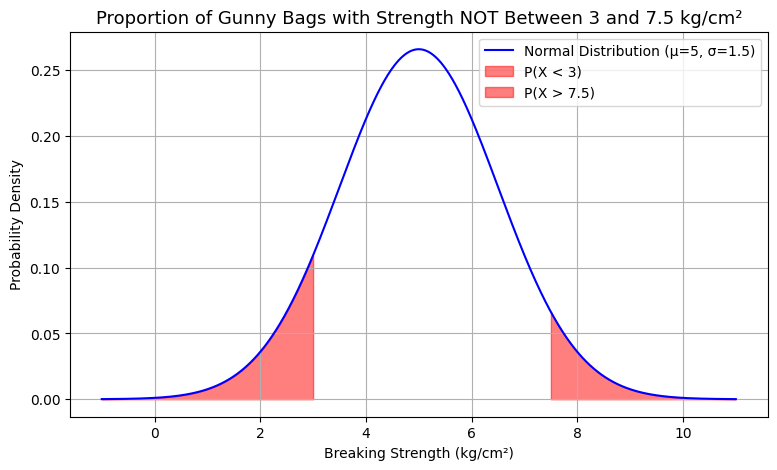

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Given parameters
mean_strength = 5       # mean (μ)
std_dev = 1.5           # standard deviation (σ)
lower_limit = 3
upper_limit = 7.5

# Step 1: Compute probability NOT between 3 and 7.5
prob_between = norm.cdf(upper_limit, mean_strength, std_dev) - norm.cdf(lower_limit, mean_strength, std_dev)
prob_not_between = 1 - prob_between

print(f"Proportion of gunny bags with breaking strength NOT between {lower_limit} and {upper_limit} kg/cm²: {prob_not_between:.4f}")

# Step 2: Create x, y for normal distribution
x = np.linspace(mean_strength - 4*std_dev, mean_strength + 4*std_dev, 1000)
y = norm.pdf(x, mean_strength, std_dev)

plt.figure(figsize=(9,5))
sns.lineplot(x=x, y=y, color='blue', label='Normal Distribution (μ=5, σ=1.5)')

# Step 3: Shade tails (X < 3 and X > 7.5)
# Left tail
x_left = np.linspace(mean_strength - 4*std_dev, lower_limit, 500)
y_left = norm.pdf(x_left, mean_strength, std_dev)
plt.fill_between(x_left, y_left, color='red', alpha=0.5, label=f'P(X < {lower_limit})')

# Right tail
x_right = np.linspace(upper_limit, mean_strength + 4*std_dev, 500)
y_right = norm.pdf(x_right, mean_strength, std_dev)
plt.fill_between(x_right, y_right, color='red', alpha=0.5, label=f'P(X > {upper_limit})')

# Step 4: Graph details
plt.title('Proportion of Gunny Bags with Strength NOT Between 3 and 7.5 kg/cm²', fontsize=13)
plt.xlabel('Breaking Strength (kg/cm²)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()